In [1]:
# ==============================================================================
# PHẦN 1: IMPORT THƯ VIỆN VÀ ĐỌC DỮ LIỆU
# ==============================================================================
import os
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV, KFold, cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import backend as K

# Ẩn các cảnh báo không cần thiết
warnings.filterwarnings('ignore')

# Hiển thị tối đa 100 cột khi xem dữ liệu
pd.set_option('display.max_columns', 100)

# Đường dẫn dữ liệu trên Kaggle
train_file = '/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv'
test_file = '/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv'

# Nếu không chạy trên Kaggle thì đọc file trong thư mục hiện tại
train = pd.read_csv(train_file if os.path.exists(train_file) else 'train.csv')
test = pd.read_csv(test_file if os.path.exists(test_file) else 'test.csv')

# Kiểm tra số dòng và số cột của hai tập dữ liệu
print(f"Kích thước ban đầu - Train: {train.shape}, Test: {test.shape}")

# Lưu cột Id để dùng khi tạo file submission
test_id = test['Id']

Kích thước ban đầu - Train: (1460, 81), Test: (1459, 80)


In [2]:
# ==============================================================================
# PHẦN 2: XỬ LÝ DỮ LIỆU
# ==============================================================================

# 1. Xử lý dữ liệu bị thiếu trong tập train
cat_col_train = [
    'FireplaceQu', 'GarageType', 'GarageFinish', 'MasVnrType', 'BsmtQual',
    'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'GarageQual', 'GarageCond'
]
ncat_col_train = ['LotFrontage', 'GarageYrBlt', 'MasVnrArea']

# Cột phân loại được điền bằng giá trị xuất hiện nhiều nhất
for col in cat_col_train:
    if col in train.columns:
        train[col] = train[col].fillna(train[col].mode()[0])

# Cột số được điền bằng giá trị trung bình
for col in ncat_col_train:
    if col in train.columns:
        train[col] = train[col].fillna(train[col].mean())

# 2. Làm tương tự với tập test
cat_col_test = [
    'FireplaceQu', 'GarageType', 'GarageFinish', 'MasVnrType', 'BsmtQual',
    'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'GarageQual', 'GarageCond', 'MSZoning', 'Utilities', 'Exterior1st',
    'Exterior2nd', 'KitchenQual', 'Functional', 'SaleType'
]
ncat_col_test = [
    'LotFrontage', 'GarageYrBlt', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
    'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath',
    'GarageCars', 'GarageArea'
]

for col in cat_col_test:
    if col in test.columns:
        test[col] = test[col].fillna(test[col].mode()[0])

for col in ncat_col_test:
    if col in test.columns:
        test[col] = test[col].fillna(test[col].mean())

# 3. Bỏ cột Id và các cột bị thiếu quá nhiều dữ liệu
to_drop = ['Id', 'Alley', 'PoolQC', 'Fence', 'MiscFeature']
train.drop(columns=to_drop, inplace=True)
test.drop(columns=to_drop, inplace=True)

# 4. Gộp train và test để các cột sau khi mã hóa giống nhau
final_df = pd.concat([train, test], axis=0)

all_cat_col = [
    'MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
    'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
    'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd',
    'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
    'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating',
    'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
    'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'PavedDrive', 'SaleType', 'SaleCondition'
]

# Chuyển các cột phân loại thành các cột số bằng One-Hot Encoding
def cat_onehot_encoding(multicol, df):
    df_final = df.copy()

    for field in multicol:
        if field in df_final.columns:
            df1 = pd.get_dummies(df_final[field], drop_first=True)
            df_final.drop([field], axis=1, inplace=True)
            df_final = pd.concat([df_final, df1], axis=1)

    return df_final


final_df = cat_onehot_encoding(all_cat_col, final_df)

# Bỏ các cột bị trùng tên sau khi mã hóa
final_df = final_df.loc[:, ~final_df.columns.duplicated()]

# 5. Tách dữ liệu trở lại thành train và test
df_train = final_df.iloc[:1460, :]
df_test = final_df.iloc[1460:, :].copy()

# Tập test không cần cột giá bán
df_test.drop(['SalePrice'], axis=1, inplace=True)

# Tách biến đầu vào và biến cần dự đoán
X_train = df_train.drop(['SalePrice'], axis=1)
y_train = df_train['SalePrice']

# Chuyển các đặc trưng về cùng kiểu dữ liệu
X_train = X_train.astype(float)
X_test = df_test.astype(float)

# Kiểm tra lại kích thước dữ liệu sau khi xử lý
print(
    f"Kích thước sau tiền xử lý - "
    f"X_train: {X_train.shape}, X_test: {X_test.shape}"
)

Kích thước sau tiền xử lý - X_train: (1460, 175), X_test: (1459, 175)


In [3]:
# ==============================================================================
# PHẦN 3: HUẤN LUYỆN VÀ DỰ ĐOÁN VỚI CÁC MÔ HÌNH
# ==============================================================================

# Tính RMSLE để so sánh kết quả giữa các mô hình
def eval_rmsle(y_true, y_pred):
    # Giới hạn dự đoán từ 1 trở lên để tránh lỗi khi lấy log
    y_pred_clipped = np.clip(y_pred, 1, None)
    return np.sqrt(mean_squared_error(np.log(y_true), np.log(y_pred_clipped)))


# ------------------------------------------------------------------------------
# MÔ HÌNH 1: DECISION TREE REGRESSOR
# Dùng mô hình hồi quy vì SalePrice là dữ liệu dạng số liên tục
# ------------------------------------------------------------------------------
print("\n--- Huấn luyện Mô hình 1: Decision Tree Regressor ---")

dt_model = DecisionTreeRegressor(max_depth=6, random_state=42)
dt_model.fit(X_train, y_train)

# Dự đoán trên tập train để xem sai số
pred_dt_train = dt_model.predict(X_train)
rmsle_dt = eval_rmsle(y_train, pred_dt_train)
print(f"RMSLE tập Train của Decision Tree: {rmsle_dt:.4f}")

# Dự đoán giá nhà của tập test và lưu kết quả
pred_dt = dt_model.predict(X_test)
sub_dt = pd.DataFrame({'Id': test_id, 'SalePrice': pred_dt})
sub_dt.to_csv('sample_sub_dt.csv', index=False)
print("Đã xuất file: sample_sub_dt.csv")


# ------------------------------------------------------------------------------
# MÔ HÌNH 2: ARTIFICIAL NEURAL NETWORK (KERAS)
# Mạng gồm ba lớp ẩn và một lớp đầu ra
# ------------------------------------------------------------------------------
print("\n--- Huấn luyện Mô hình 2: Artificial Neural Network (ANN) ---")


# Hàm tính RMSE dùng khi huấn luyện mạng
def root_mean_squared_error(y_true, y_pred):
    return K.sqrt(K.mean(K.square(y_pred - y_true)))


# Tạo cấu trúc cho mạng neural
nn_model = Sequential([
    Dense(
        50,
        kernel_initializer='he_uniform',
        activation='relu',
        input_dim=X_train.shape[1]
    ),
    Dense(25, kernel_initializer='he_uniform', activation='relu'),
    Dense(50, kernel_initializer='he_uniform', activation='relu'),
    Dense(1, kernel_initializer='he_uniform')
])

# Chọn hàm mất mát và thuật toán tối ưu
nn_model.compile(
    loss=root_mean_squared_error,
    optimizer='Adamax'
)

# Dùng 25% dữ liệu train để kiểm tra trong lúc huấn luyện
history = nn_model.fit(
    X_train.values,
    y_train.values,
    validation_split=0.25,
    batch_size=10,
    epochs=100,
    verbose=0
)

# Kiểm tra sai số của mạng trên tập train
pred_nn_train = nn_model.predict(X_train.values).flatten()
rmsle_nn = eval_rmsle(y_train, pred_nn_train)
print(f"RMSLE tập Train của Artificial Neural Network: {rmsle_nn:.4f}")

# Lưu mô hình và kết quả dự đoán
nn_model.save('nn_model.h5')

pred_nn = nn_model.predict(X_test.values).flatten()
sub_nn = pd.DataFrame({'Id': test_id, 'SalePrice': pred_nn})
sub_nn.to_csv('sample_sub_nn.csv', index=False)
print("Đã xuất file: sample_sub_nn.csv")


# ------------------------------------------------------------------------------
# MÔ HÌNH 3: XGBOOST REGRESSOR
# Thử một số bộ tham số bằng RandomizedSearchCV
# ------------------------------------------------------------------------------
print("\n--- Huấn luyện Mô hình 3: XGBoost Regressor ---")

# Khởi tạo mô hình XGBoost ban đầu
xgb_base = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

# Các giá trị tham số sẽ được đưa vào thử nghiệm
param_distributions = {
    'n_estimators': [100, 500, 900, 1100],
    'max_depth': [2, 3, 5, 6],
    'learning_rate': [0.05, 0.1, 0.15],
    'min_child_weight': [1, 2, 3],
    'booster': ['gbtree'],
    'base_score': [0.25, 0.5]
}

# Thử ngẫu nhiên 10 bộ tham số và đánh giá bằng cross-validation 5 lần
random_cv = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions,
    cv=5,
    n_iter=10,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Huấn luyện và lấy mô hình có kết quả tốt nhất
random_cv.fit(X_train, y_train)
best_xgb = random_cv.best_estimator_

print(f"Tham số tối ưu của XGBoost: {random_cv.best_params_}")

# Kiểm tra sai số trên tập train
pred_xgb_train = best_xgb.predict(X_train)
rmsle_xgb = eval_rmsle(y_train, pred_xgb_train)
print(f"RMSLE tập Train của XGBoost: {rmsle_xgb:.4f}")

# Lưu lại mô hình XGBoost
with open('xgb_model.pkl', 'wb') as f:
    pickle.dump(best_xgb, f)

# Dự đoán tập test và tạo file kết quả
pred_xgb = best_xgb.predict(X_test)
sub_xgb = pd.DataFrame({'Id': test_id, 'SalePrice': pred_xgb})
sub_xgb.to_csv('sample_sub_xgb.csv', index=False)
print("Đã xuất file: sample_sub_xgb.csv")


# ------------------------------------------------------------------------------
# MÔ HÌNH 4: RANDOM FOREST REGRESSOR
# ------------------------------------------------------------------------------
print("\n--- Huấn luyện Mô hình 4: Random Forest Regressor ---")

# Khởi tạo và huấn luyện Random Forest
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Kiểm tra sai số trên tập train
pred_rf_train = rf_model.predict(X_train)
rmsle_rf = eval_rmsle(y_train, pred_rf_train)
print(f"RMSLE tập Train của Random Forest: {rmsle_rf:.4f}")

# Dự đoán tập test và tạo file kết quả
pred_rf = rf_model.predict(X_test)
sub_rf = pd.DataFrame({'Id': test_id, 'SalePrice': pred_rf})
sub_rf.to_csv('sample_sub_rf.csv', index=False)
print("Đã xuất file: sample_sub_rf.csv")


--- Huấn luyện Mô hình 1: Decision Tree Regressor ---
RMSLE tập Train của Decision Tree: 0.1519
Đã xuất file: sample_sub_dt.csv

--- Huấn luyện Mô hình 2: Artificial Neural Network (ANN) ---


2026-09-18 15:11:18.390193: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


RMSLE tập Train của Artificial Neural Network: 0.2054
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Đã xuất file: sample_sub_nn.csv

--- Huấn luyện Mô hình 3: XGBoost Regressor ---
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Tham số tối ưu của XGBoost: {'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.05, 'booster': 'gbtree', 'base_score': 0.5}
RMSLE tập Train của XGBoost: 0.0750
Đã xuất file: sample_sub_xgb.csv

--- Huấn luyện Mô hình 4: Random Forest Regressor ---
RMSLE tập Train của Random Forest: 0.0720
Đã xuất file: sample_sub_rf.csv


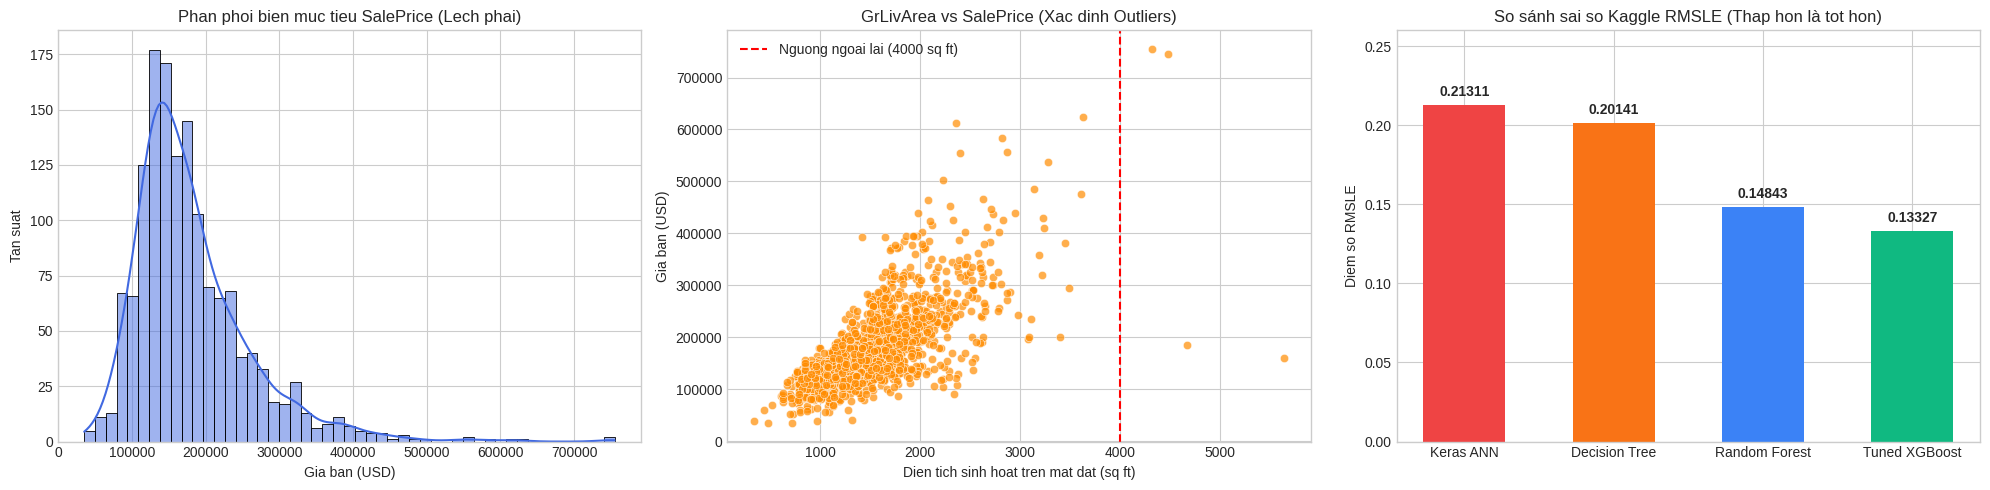

In [4]:
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Biểu đồ 1: Phân phối giá nhà (minh họa hiện tượng lệch phải ở Pha 2)
sns.histplot(train['SalePrice'], kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('Phan phoi bien muc tieu SalePrice (Lech phai)')
axes[0].set_xlabel('Gia ban (USD)')
axes[0].set_ylabel('Tan suat')

# Biểu đồ 2: Quan hệ diện tích và giá nhà (tìm điểm ngoại lai > 4000 sq ft theo paper De Cock)
sns.scatterplot(x=train['GrLivArea'], y=train['SalePrice'], ax=axes[1], color='darkorange', alpha=0.7)
axes[1].axvline(x=4000, color='red', linestyle='--', label='Nguong ngoai lai (4000 sq ft)')
axes[1].set_title('GrLivArea vs SalePrice (Xac dinh Outliers)')
axes[1].set_xlabel('Dien tich sinh hoat tren mat dat (sq ft)')
axes[1].set_ylabel('Gia ban (USD)')
axes[1].legend()

# Biểu đồ 3: So sánh điểm số sai số RMSLE thực tế của 4 mô hình trên Kaggle (Pha 5)
models = ['Keras ANN', 'Decision Tree', 'Random Forest', 'Tuned XGBoost']
scores = [0.21311, 0.20141, 0.14843, 0.13327]
colors = ['#ef4444', '#f97316', '#3b82f6', '#10b981']

bars = axes[2].bar(models, scores, color=colors, width=0.55)
axes[2].set_title('So sánh sai so Kaggle RMSLE (Thap hon là tot hon)')
axes[2].set_ylabel('Diem so RMSLE')
axes[2].set_ylim(0, 0.26)

for bar in bars:
    height = bar.get_height()
    axes[2].annotate(f'{height:.5f}',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 4), textcoords='offset points',
                     ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [5]:
import sys

!"{sys.executable}" -m nbconvert --to html "house-prices-predict.ipynb" --output "lab02_execution_log.html"

[NbConvertApp] Converting notebook house-prices-predict.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 505069 bytes to lab02_execution_log.html
